In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dspl_generator import DSPLGenerator

/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gen = DSPLGenerator(15, lens_img='data/euclid_deep_VIS1.npy', source1_img=None, source2_img='data/euclid_deep_VIS2.npy', telescope='euclid')

In [3]:
lens_image, mass_kwargs, light_kwargs, eta_flat = gen.get_lens_image()

In [4]:
model = gen.get_model()
sim = gen.get_simulation()

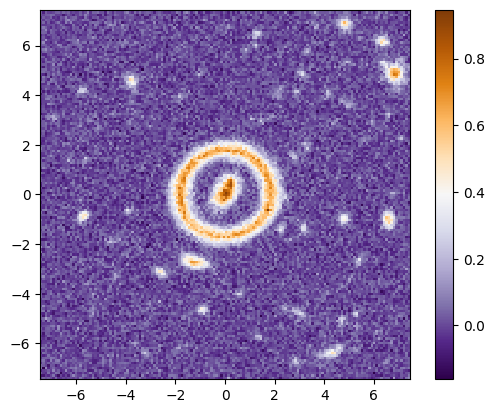

In [5]:
plt.imshow(sim, origin='lower', cmap='PuOr_r', extent=gen.pixel_grid.extent)
plt.colorbar()
plt.show()

In [6]:
gen.shuffle()

In [7]:
mu_lens, mu_s1 = gen.get_magnification()
lens_cc, s1_cc = gen.get_critical_curves()

s1_caustics, s2_caustics = gen.get_caustics()

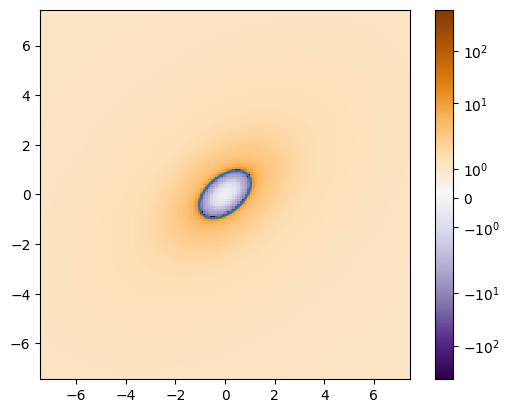

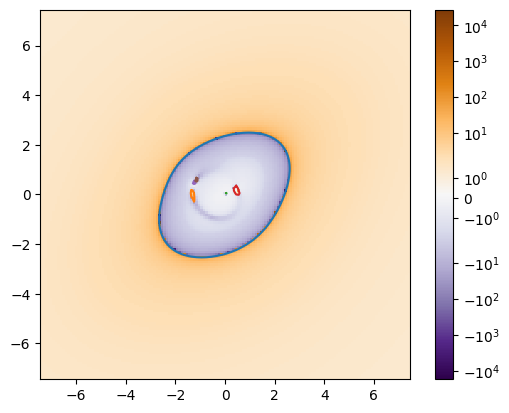

In [8]:
plt.imshow(mu_lens, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for c in lens_cc:
    plt.plot(c[:, 0], c[:, 1])
plt.colorbar()
plt.show()

plt.imshow(mu_s1, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for c in s1_cc:
    plt.plot(c[:, 0], c[:, 1])
plt.colorbar()
plt.show()

In [9]:
def get_caustics(curve):
    """
    get the caustics on source1 and source2

    Returns
    -------
    contours_phys_lens : list[points]
        A list of points which give the lens effective critical curves. Each curve is a different nested list.
    contours_phys_s1 : list[points]
        A list of points which give the source1 critical curves. Each curve is a different nested list.
    """
    s1_caustics = []
    s2_caustics = []
    for curve in lens_cc:
        x_img = jnp.array(curve[:, 0])
        y_img = jnp.array(curve[:, 1])
        
        x_deflected, y_deflected = gen.mass_model.ray_shooting(x_img, y_img, eta_flat=gen.eta, kwargs=gen.mass_kwargs)
        x_s1 = x_deflected.T[:, 1]
        y_s1 = y_deflected.T[:, 1]

        x_s2 = x_deflected.T[:, 2]
        y_s2 = y_deflected.T[:, 2]
        
        s1_caustics.append(np.column_stack([np.array(x_s1), np.array(y_s1)]))
        s2_caustics.append(np.column_stack([np.array(x_s2), np.array(y_s2)]))

    return s1_caustics, s2_caustics

In [10]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dspl_generator import DSPLGenerator

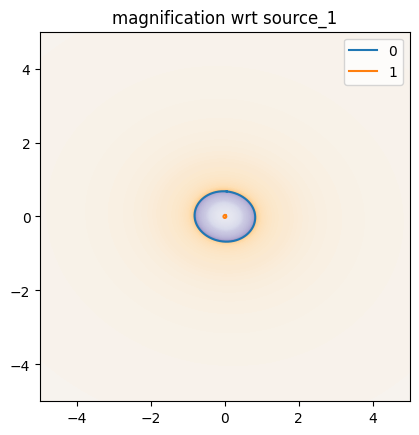

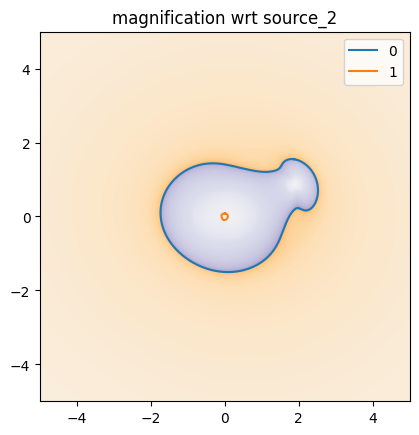

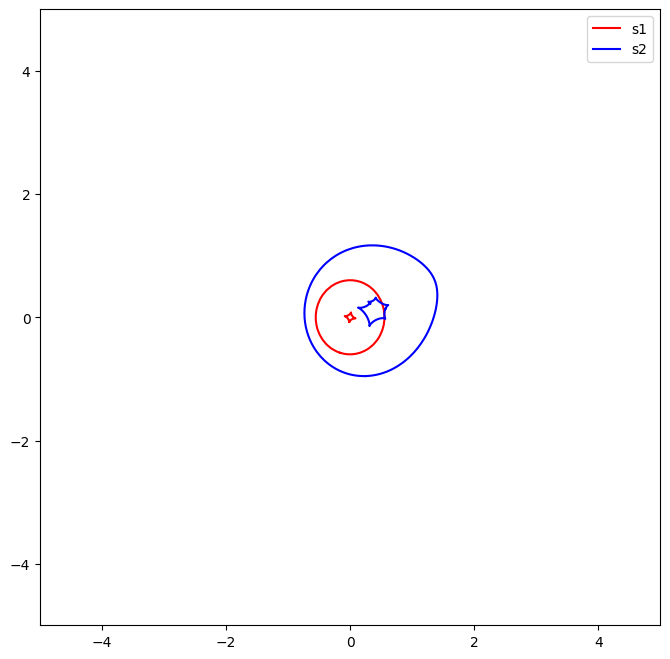

In [11]:
gen = DSPLGenerator(10, lens_img='data/euclid_deep_VIS1.npy', source1_img=None, source2_img='data/euclid_deep_VIS2.npy', telescope='example')


mu_lens, mu_s1 = gen.get_magnification()
lens_cc, s1_cc = gen.get_critical_curves()

plt.imshow(mu_lens, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for i, c in enumerate(lens_cc):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.title("magnification wrt source_1")
plt.legend()
plt.show()

plt.imshow(mu_s1, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for i, c in enumerate(s1_cc):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.title("magnification wrt source_2")
plt.legend()
plt.show()


s1_caustics, s2_caustics = gen.get_caustics()


plt.figure(figsize=(8,8))

for i, c in enumerate(s1_caustics):
    if i==0:
        plt.plot(c[:,0], c[:,1], c='red', label='s1')
    else:
        plt.plot(c[:,0], c[:,1], c='red')

for i, c in enumerate(s2_caustics):
    if i==0:
        plt.plot(c[:,0], c[:,1], c='blue', label='s2')
    else:
        plt.plot(c[:,0], c[:,1], c='blue')


x_min, x_max, y_min, y_max = gen.pixel_grid.extent

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend()
plt.savefig("figures_out/caustics_dspl10.png")
plt.show()
